#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from tree_sitter_languages import get_parser

from concurrent.futures import ThreadPoolExecutor

import math
from collections import Counter

import matplotlib.pyplot as plt


#### Loading Dataset

In [2]:
train_df = pd.read_parquet("../data/task_a/train.parquet")
val_df   = pd.read_parquet("../data/task_a/val.parquet")
test_df  = pd.read_parquet("../data/task_a/test_sample.parquet")

print(train_df.shape, val_df.shape, test_df.shape)

(500000, 4) (100000, 4) (1000, 4)


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### Setup tree-sitter Parsers

In [4]:
parsers = {
    "Python": get_parser("python"),
    "Java": get_parser("java"),
    "C++": get_parser("cpp")
}

#### AST Scalar Feature Extraction

In [5]:
def extract_ast_features(code, language):

    parser = parsers.get(language)

    if parser is None:
        return [0]*18

    try:
        tree = parser.parse(bytes(code, "utf8"))
        root = tree.root_node
    except:
        return [0]*18

    stack = [(root,0)]

    total_nodes = 0
    leaf_nodes = 0
    depths = []
    children_counts = []
    node_types = []

    decision_nodes = 0
    function_calls = 0
    call_types = set()

    while stack:

        node, depth = stack.pop()

        total_nodes += 1
        depths.append(depth)

        node_types.append(node.type)

        children = node.children
        children_counts.append(len(children))

        if len(children) == 0:
            leaf_nodes += 1

        if node.type in ["if_statement","for_statement","while_statement"]:
            decision_nodes += 1

        if "call" in node.type:
            function_calls += 1
            call_types.add(node.type)

        for child in children:
            stack.append((child, depth+1))

    # ----- depth statistics -----
    max_depth = max(depths) if depths else 0
    avg_depth = np.mean(depths) if depths else 0
    depth_var = np.var(depths) if depths else 0

    # ----- branching -----
    leaf_ratio = leaf_nodes/(total_nodes+1)

    avg_branch = np.mean(children_counts) if children_counts else 0
    max_children = max(children_counts) if children_counts else 0
    branch_variance = np.var(children_counts) if children_counts else 0

    # ----- cyclomatic complexity -----
    cyclomatic = decision_nodes + 1

    # ----- node diversity -----
    unique_types = len(set(node_types))

    # ----- entropy of node types -----
    if total_nodes > 0:
        counts = Counter(node_types)
        probs = [v/total_nodes for v in counts.values()]
        entropy = -sum(p*math.log(p + 1e-10) for p in probs)
    else:
        entropy = 0

    # ----- normalized entropy -----
    num_types = len(counts) if total_nodes > 0 else 0
    if num_types > 1:
        norm_entropy = entropy / math.log(num_types)
    else:
        norm_entropy = 0

    # ----- branch entropy -----
    if children_counts:
        branch_counts = Counter(children_counts)
        total_branches = len(children_counts)
        probs = [v/total_branches for v in branch_counts.values()]
        branch_entropy = -sum(p*math.log(p + 1e-10) for p in probs)
    else:
        branch_entropy = 0

    # ----- call statistics -----
    unique_calls = len(call_types)

    internal_nodes = total_nodes - leaf_nodes

    return [
        max_depth,
        avg_depth,
        depth_var,
        total_nodes,
        leaf_nodes,
        leaf_ratio,
        avg_branch,
        max_children,
        branch_variance,
        cyclomatic,
        decision_nodes,
        unique_types,
        entropy,
        norm_entropy,
        branch_entropy,
        function_calls,
        unique_calls,
        internal_nodes
    ]

#### Parallel Feature Extraction

In [6]:
def parallel_feature_extraction(df, max_workers=12):

    codes = df["code"].tolist()
    langs = df["language"].tolist()

    tasks = list(zip(codes,langs))

    features = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:

        for feat in tqdm(executor.map(lambda x: extract_ast_features(*x), tasks),
                         total=len(tasks)):
            features.append(feat)

    return np.array(features)

#### Extracting Features for Entire Dataset

In [7]:
X_train = parallel_feature_extraction(train_df)

X_val   = parallel_feature_extraction(val_df)

X_test  = parallel_feature_extraction(test_df)

100%|██████████| 1000/1000 [00:00<00:00, 7213.86it/s]


#### Extracting Labels

In [8]:
y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

#### saving Features

In [9]:
np.save("../data/X_train_ast_scalars.npy", X_train)
np.save("../data/X_val_ast_scalars.npy", X_val)
np.save("../data/X_test_ast_scalars.npy", X_test)

#### using saved npy

In [10]:
X_train = np.load("../data/X_train_ast_scalars.npy")
X_val   = np.load("../data/X_val_ast_scalars.npy")
X_test  = np.load("../data/X_test_ast_scalars.npy")

#### Verifying Feature Matrix

In [11]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(500000, 18)
(100000, 18)
(1000, 18)


#### Import ML related Libraries

In [12]:
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

## Train Models

### Random Forest

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### SVM (Linear SVM for large dataset)

In [14]:
svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


### CatBoost

In [15]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=100
)

cat_model.fit(X_train, y_train)

0:	learn: 0.6642627	total: 226ms	remaining: 1m 52s
100:	learn: 0.4911032	total: 4.75s	remaining: 18.8s
200:	learn: 0.4727178	total: 9.39s	remaining: 14s
300:	learn: 0.4617526	total: 14.4s	remaining: 9.51s
400:	learn: 0.4542045	total: 19s	remaining: 4.7s
499:	learn: 0.4481751	total: 23.4s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, verbose=100)

### Evaluation Function

In [16]:
def evaluate_model(model, X_test, y_test, model_name):

    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        probs = model.decision_function(X_test)

    print("\n======", model_name, "======")

    acc = accuracy_score(y_test, preds)
    f1_bin = f1_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    prec = precision_score(y_test, preds, average="macro")
    rec = recall_score(y_test, preds, average="macro")
    auc = roc_auc_score(y_test, probs)

    print("Accuracy:", acc)
    print("Binary F1:", f1_bin)
    print("Macro F1:", f1_macro)
    print("Macro Precision:", prec)
    print("Macro Recall:", rec)
    print("ROC AUC:", auc)

    print("\nClassification Report")
    print(classification_report(y_test, preds))

    return probs

### Evaluating All Models

#### validation Data

In [17]:
rf_val_probs = evaluate_model(rf_model, X_val, y_val, "Random Forest (Validation)")

svm_val_probs = evaluate_model(svm_model, X_val, y_val, "SVM (Validation)")

cat_val_probs = evaluate_model(cat_model, X_val, y_val, "CatBoost (Validation)")


====== Random Forest (Validation) ======
Accuracy: 0.78017
Binary F1: 0.7722228554258064
Macro F1: 0.779902072129218
Macro Precision: 0.7866907676265593
Macro Recall: 0.7834434107710047
ROC AUC: 0.8656781193961218

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.85      0.79     47695
           1       0.84      0.71      0.77     52305

    accuracy                           0.78    100000
   macro avg       0.79      0.78      0.78    100000
weighted avg       0.79      0.78      0.78    100000


====== SVM (Validation) ======
Accuracy: 0.68972
Binary F1: 0.6659273455500765
Macro F1: 0.6881381467393033
Macro Precision: 0.701218632451865
Macro Recall: 0.6944791560472231
ROC AUC: 0.7628649221612263

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.80      0.71     47695
           1       0.76      0.59      0.67     52305

    accuracy                           0.69

#### Test Data

In [18]:
rf_probs = evaluate_model(rf_model, X_test, y_test, "Random Forest")

svm_probs = evaluate_model(svm_model, X_test, y_test, "SVM")

cat_probs = evaluate_model(cat_model, X_test, y_test, "CatBoost")


====== Random Forest ======
Accuracy: 0.357
Binary F1: 0.3751214771622935
Macro F1: 0.3564587818355237
Macro Precision: 0.542407459517536
Macro Recall: 0.5382695315430741
ROC AUC: 0.6075800335890021

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.21      0.34       777
           1       0.24      0.87      0.38       223

    accuracy                           0.36      1000
   macro avg       0.54      0.54      0.36      1000
weighted avg       0.71      0.36      0.35      1000


====== SVM ======
Accuracy: 0.387
Binary F1: 0.3457844183564568
Macro F1: 0.3845573079552745
Macro Precision: 0.5068020215079039
Macro Recall: 0.5080163443392143
ROC AUC: 0.5110462801045761

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.29      0.42       777
           1       0.23      0.73      0.35       223

    accuracy                           0.39      1000
   macro avg      

### ROC Curve Visualization

#### ROC for Validation

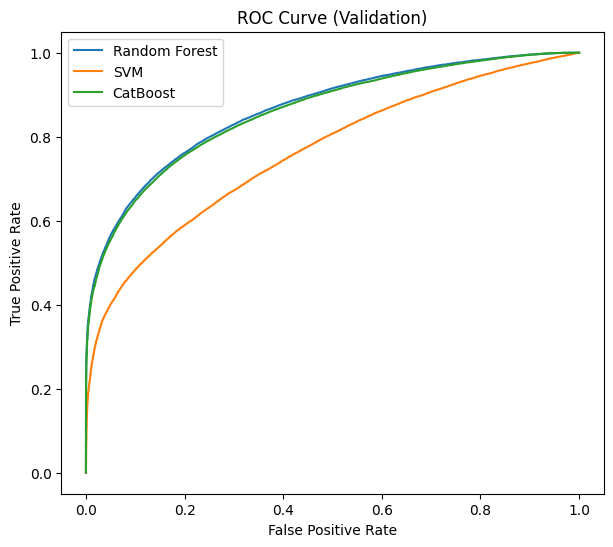

In [19]:
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_val, svm_val_probs)
fpr_cat, tpr_cat, _ = roc_curve(y_val, cat_val_probs)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_cat, tpr_cat, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")

plt.legend()

plt.savefig("../data/roc_curve_ast_scalars_validation.png")

plt.show()

#### ROC for Test data

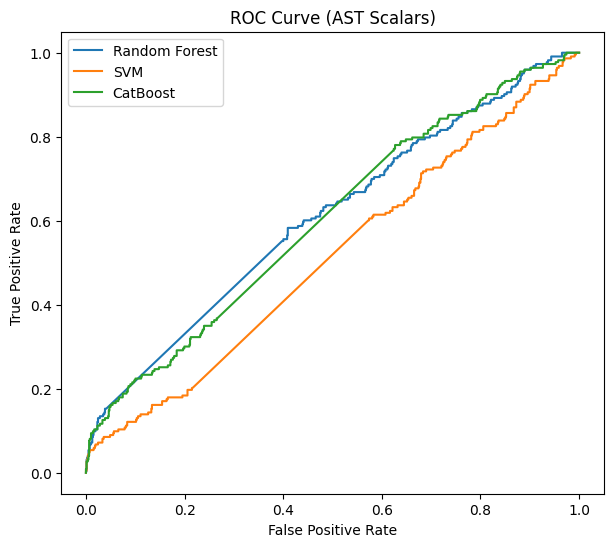

In [20]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_probs)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_cat, tpr_cat, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AST Scalars)")

plt.legend()

plt.savefig("../data/roc_curve_ast_scalars.png")

plt.show()

### SHAP Interpretability

In [21]:
feature_names = [
"max_depth",
"avg_depth",
"depth_var",
"total_nodes",
"leaf_nodes",
"leaf_ratio",
"avg_branch",
"max_children",
"branch_variance",
"cyclomatic",
"decision_nodes",
"unique_types",
"entropy",
"norm_entropy",
"branch_entropy",
"function_calls",
"unique_calls",
"internal_nodes"
]

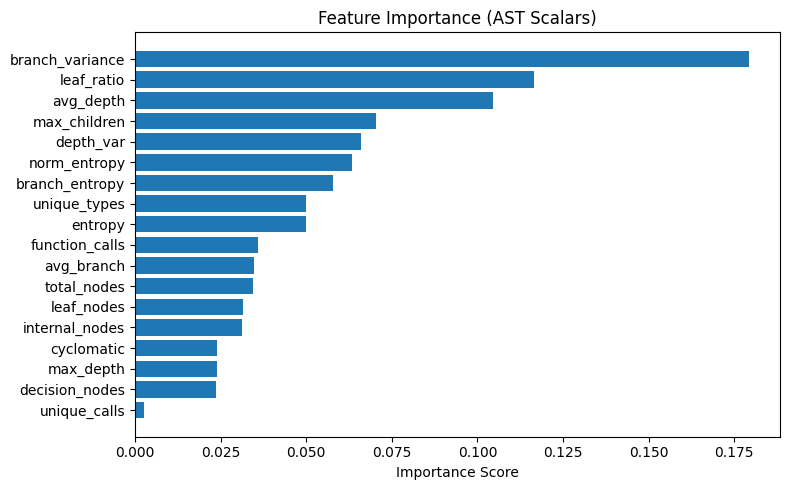

In [22]:
importances = rf_model.feature_importances_

sorted_idx = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])

plt.title("Feature Importance (AST Scalars)")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.savefig("../data/feature_importance_ast_scalars.png")

plt.show()

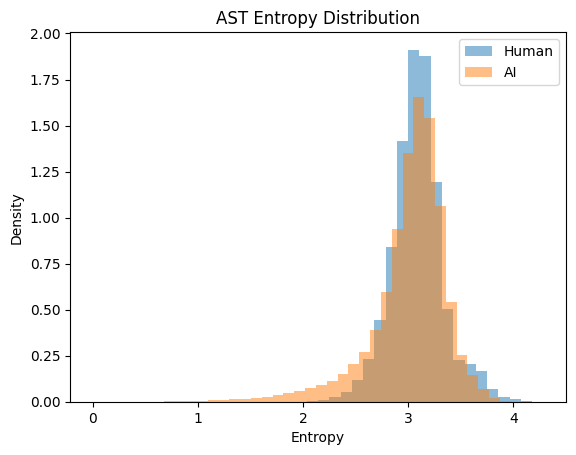

In [23]:
entropy_idx = feature_names.index("entropy")

human_entropy = X_train[y_train == 0][:, entropy_idx]
ai_entropy = X_train[y_train == 1][:, entropy_idx]

plt.hist(human_entropy, bins=40, alpha=0.5, density=True, label="Human")
plt.hist(ai_entropy, bins=40, alpha=0.5, density=True, label="AI")

plt.title("AST Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Density")

plt.legend()
plt.show()

In [24]:
import pandas as pd

importances = rf_model.feature_importances_

# ensure same length
feature_names_fixed = feature_names[:len(importances)]

importance_df = pd.DataFrame({
    "feature": feature_names_fixed,
    "importance": importances
})

importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df)

            feature  importance
8   branch_variance    0.179399
5        leaf_ratio    0.116543
1         avg_depth    0.104574
7      max_children    0.070270
2         depth_var    0.065921
13     norm_entropy    0.063345
14   branch_entropy    0.057880
11     unique_types    0.049846
12          entropy    0.049774
15   function_calls    0.035920
6        avg_branch    0.034794
3       total_nodes    0.034564
4        leaf_nodes    0.031380
17   internal_nodes    0.031264
9        cyclomatic    0.024058
0         max_depth    0.024052
10   decision_nodes    0.023735
16     unique_calls    0.002680


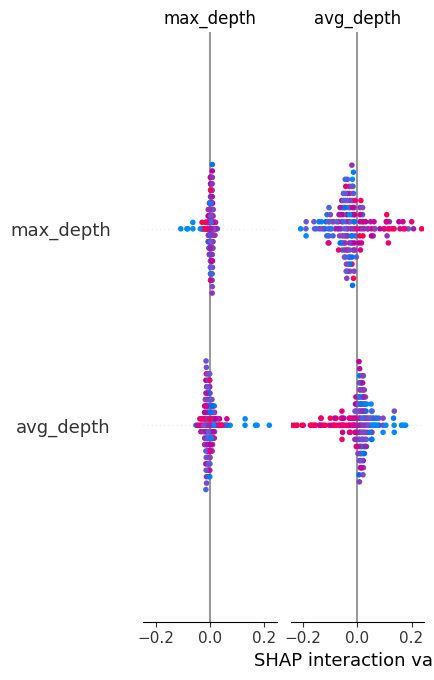

In [25]:
# Random 200 samples from validation set
idx = np.random.choice(len(X_val), 200, replace=False)
X_shap = X_val[idx]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.savefig("../data/shap_summary_ast_scalars.png")

C:\Users\yoges\AppData\Local\Temp\ipykernel_22048\799595173.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([human_entropy, ai_entropy], labels=["Human Code", "AI Code"])


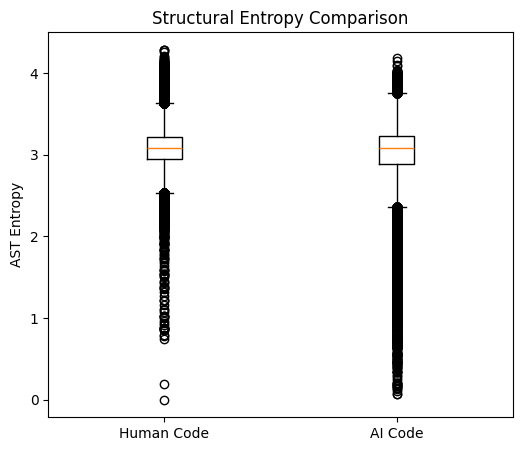

In [26]:
entropy_idx = feature_names.index("entropy")

human_entropy = X_train[y_train == 0][:, entropy_idx]
ai_entropy = X_train[y_train == 1][:, entropy_idx]

plt.figure(figsize=(6,5))

plt.boxplot([human_entropy, ai_entropy], labels=["Human Code", "AI Code"])

plt.ylabel("AST Entropy")
plt.title("Structural Entropy Comparison")

plt.savefig("../data/entropy_boxplot.png", dpi=300)

plt.show()

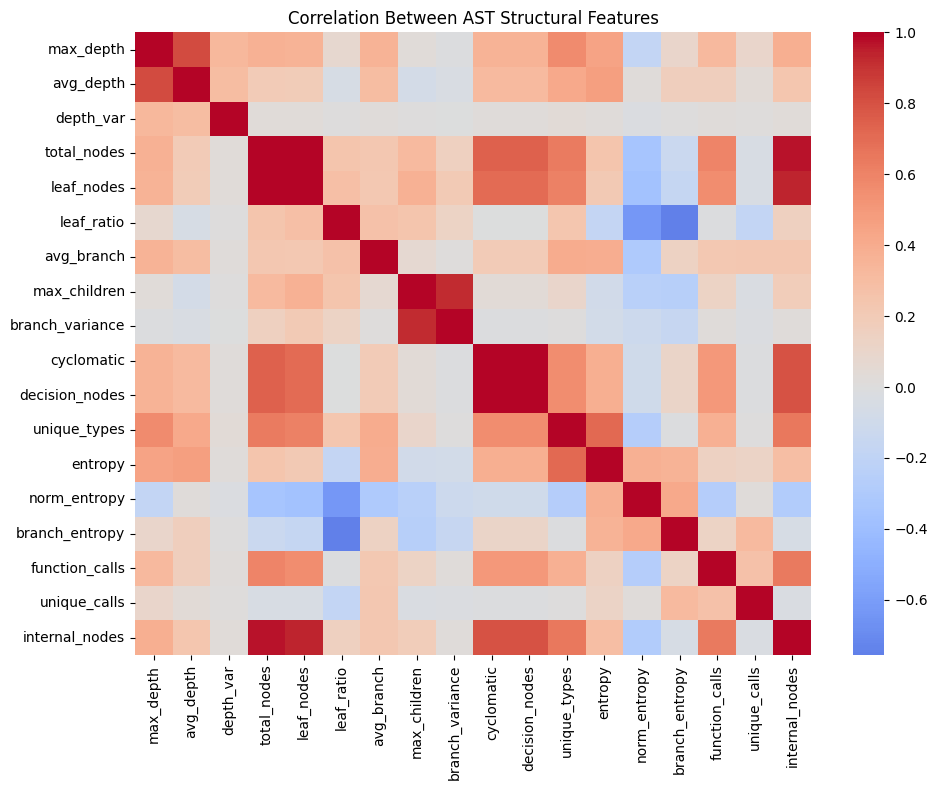

In [27]:
import seaborn as sns

df_features = pd.DataFrame(X_train, columns=feature_names)

plt.figure(figsize=(10,8))

sns.heatmap(df_features.corr(), cmap="coolwarm", center=0)

plt.title("Correlation Between AST Structural Features")

plt.tight_layout()

plt.savefig("../data/feature_correlation_ast.png")

plt.show()

### Model Comparison Table

In [28]:
results = []

for name, model in [
    ("Random Forest", rf_model),
    ("SVM", svm_model),
    ("CatBoost", cat_model)
]:

    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Macro F1": f1_score(y_test, preds, average="macro")
    })

pd.DataFrame(results)

,Model,Accuracy,F1,Macro F1
0,Random Forest,0.357,0.375121,0.356459
1,SVM,0.387,0.345784,0.384557
2,CatBoost,0.363,0.376102,0.362719


We trained classical machine learning models on the 15 AST scalar features extracted from each code snippet.

These features capture structural characteristics of programs such as tree depth, branching patterns, and control-flow complexity.

Unlike lexical models such as TF-IDF, AST features focus on the syntactic shape of the program, enabling the model to detect structural regularities typical of machine-generated code.

This experiment evaluates whether structural programming patterns alone are sufficient for detecting machine-generated code.
AST scalar features capture high-level structural properties of programs,
such as tree depth, branching factor, and control flow complexity.

Random Forest achieved the best validation performance (F1 = 0.77),
suggesting that non-linear interactions between structural features
are important for distinguishing machine-generated code.

However, evaluation on the cross-language test set revealed a large
performance drop (F1 ≈ 0.38), indicating that structural statistics
alone are insufficient for robust cross-language generalization.